In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

In [21]:
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
#mapdf = pd.read_csv('/home/kale-chen/Documents/PET/LUT.txt', sep = ' ', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()
print(np.min(map[:,0]), np.max(map[:,0]), np.min(map[:,1]), np.max(map[:,1]), np.min(map[:,2]), np.max(map[:,2]))
print(map[0:3])

-167.902272 167.902272 -134.6722331 134.6722339 -50.8 50.8
[[ 117.3250734  -120.1245968    38.            0.64944805   -0.76040597
     0.        ]
 [ 114.8917743  -122.2028306    38.            0.64944805   -0.76040597
     0.        ]
 [ 112.4584752  -124.2810643    28.4           0.64944805   -0.76040597
     0.        ]]


In [ ]:
# Tools to adjust the map
def center_onto_zero(map, axis):
    midpoint = (max(map[:,axis]) + min(map[:,axis])) / 2
    map[:,axis] = map[:,axis] - midpoint
    return map


In [27]:
mapcopy = map.copy()
for row in mapcopy:
    row[3] = -row[3]
    if row[1] < 0:
        row[4] = -row[4]

In [47]:
mapcopy = map.copy()
print(np.unique(mapcopy[:,2]))

[-50.8 -47.6 -44.4 -41.2 -38.  -34.8 -31.6 -28.4 -24.4 -21.2 -18.  -14.8
 -11.6  -8.4  -5.2  -2.    2.    5.2   8.4  11.6  14.8  18.   21.2  24.4
  28.4  31.6  34.8  38.   41.2  44.4  47.6  50.8]


In [48]:
mapcopy = map.copy()
for row in mapcopy:
    if row[0] < 0:
        if row[2] > 0:
            row[2] = row[2] - 52.8
        else:
            row[2] = row[2] + 52.8
print(mapcopy)

[[ 117.3250734  -120.1245968    38.            0.64944805   -0.76040597
     0.        ]
 [ 114.8917743  -122.2028306    38.            0.64944805   -0.76040597
     0.        ]
 [ 112.4584752  -124.2810643    28.4           0.64944805   -0.76040597
     0.        ]
 ...
 [-105.158578   -130.5157656    18.           -0.64944805   -0.76040597
     0.        ]
 [-107.5918771  -128.4375319    24.4          -0.64944805   -0.76040597
     0.        ]
 [-100.2919798  -134.6722331    14.8          -0.64944805   -0.76040597
     0.        ]]


In [49]:
import pandas as pd

# Write mapcopy to a CSV file
mapcopy_df = pd.DataFrame(mapcopy)
mapcopy_df.to_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted_modified.csv', index=False, header=False)

FileNotFoundError: [Errno 2] No such file or directory: '/home/kale-chen/Documents/PET/TimeCalibration/ImagesForPaper/ChannelHalves.pdf'

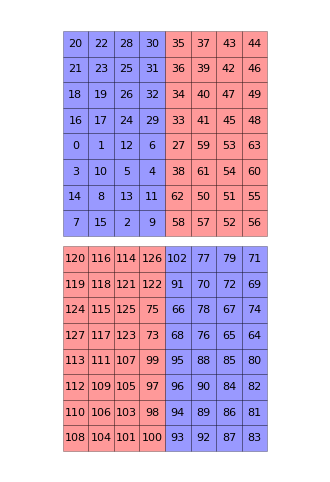

In [35]:
fig, ax = plt.subplots(figsize=(4, 6))
import matplotlib.patches as patches
indices = {
      0 : (4,7-7),
      1 : (4,7-6),
      2 : (7,7-5),
      3 : (5,7-7),
      4 : (5,7-4),
      5 : (5,7-5),
      6 : (4,7-4),
      7 : (7,7-7),
      8 : (6,7-6),
      9 : (7,7-4),
      10 : (5,7-6),
      11 : (6,7-4),
      12 : (4,7-5),
      13 : (6,7-5),
      14 : (6,7-7),
      15 : (7,7-6),
      16 : (3,7-7),
      17 : (3,7-6),
      18 : (2,7-7),
      19 : (2,7-6),
      20 : (0,7-7),
      21 : (1,7-7),
      22 : (0,7-6),
      23 : (1,7-6),
      24 : (3,7-5),
      25 : (1,7-5),
      26 : (2,7-5),
      27 : (4,7-3),
      28 : (0,7-5),
      29 : (3,7-4),
      30 : (0,7-4),
      31 : (1,7-4),
      32 : (2,7-4),
      33 : (3,7-3),
      34 : (2,7-3),
      35 : (0,7-3),
      36 : (1,7-3),
      37 : (0,7-2),
      38 : (5,7-3),
      39 : (1,7-2),
      40 : (2,7-2),
      41 : (3,7-2),
      42 : (1,7-1),
      43 : (0,7-1),
      44 : (0,7-0),
      45 : (3,7-1),
      46 : (1,7-0),
      47 : (2,7-1),
      48 : (3,7-0),
      49 : (2,7-0),
      50 : (6,7-2),
      51 : (6,7-1),
      52 : (7,7-1),
      53 : (4,7-1),
      54 : (5,7-1),
      55 : (6,7-0),
      56 : (7,7-0),
      57 : (7,7-2),
      58 : (7,7-3),
      59 : (4,7-2),
      60 : (5,7-0),
      61 : (5,7-2),
      62 : (6,7-3),
      63 : (4,7-0),
      64:(3+8,7),
      65:(3+8,6),
      66:(2+8,4),
      67:(2+8,6),
      68:(3+8,4),
      69:(1+8,7),
      70:(1+8,5),
      71:(0+8,7),
      72:(1+8,6),
      73:(3+8,3),
      74:(2+8,7),
      75:(2+8,3),
      76:(3+8,5),
      77:(0+8,5),
      78:(2+8,5),
      79:(0+8,6),
      80:(4+8,7),
      81:(6+8,7),
      82:(5+8,7),
      83:(7+8,7),
      84:(5+8,6),
      85:(4+8,6),
      86:(6+8,6),
      87:(7+8,6),
      88:(4+8,5),
      89:(6+8,5),
      90:(5+8,5),
      91:(1+8,4),
      92:(7+8,5),
      93:(7+8,4),
      94:(6+8,4),
      95:(4+8,4),
      96:(5+8,4),
      97:(5+8,3),
      98:(6+8,3),
      99:(4+8,3),
      100:(7+8,3),
      101:(7+8,2),
      102:(0+8,4),
      103:(6+8,2),
      104:(7+8,1),
      105:(5+8,2),
      106:(6+8,1),
      107:(4+8,2),
      108:(7+8,0),
      109:(5+8,1),
      110:(6+8,0),
      111:(4+8,1),
      112:(5+8,0),
      113:(4+8,0),
      114:(0+8,2),
      115:(2+8,1),
      116:(0+8,1),
      117:(3+8,1),
      118:(1+8,1),
      119:(1+8,0),
      120:(0+8,0),
      121:(1+8,2),
      122:(1+8,3),
      123:(3+8,2),
      124:(2+8,0),
      125:(2+8,2),
      126:(0+8,3),
      127:(3+8,0)}

half1=np.asarray(list(range(0, 27)) + list(range(28, 33)) + list(range(64, 73)) + list(range(76, 97)) + [74, 102])

for n in range(0, 128):
    # Use the indices dictionary to get positions
    if n in indices:
        y, x = indices[n]
        y = 15 - y
        if y >= 8:
            y += 0.4
        facecolor = 'blue' if n in half1 else 'red'
        rect = patches.Rectangle((x, y), 1, 1, linewidth=0.5, edgecolor='black', facecolor=facecolor, alpha=0.4)
        ax.add_patch(rect)
        ax.text(x + 0.5, y + 0.5, str(n), fontsize=8, ha='center', va='center')
    else:
        continue

plt.tick_params(axis='both', which='both', bottom=False, top=False,
                left=False, right=False, labelbottom=False, labelleft=False)
for spine in ax.spines.values():
    spine.set_visible(False)
plt.ylim(0, 16)
plt.xlim(0, 8)
plt.axis('equal')
plt.savefig(r'/home/kale-chen/Documents/PET/TimeCalibration/ImagesForPaper/ChannelHalves.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()

-159.0728311 53.76733198 14.800000000000004


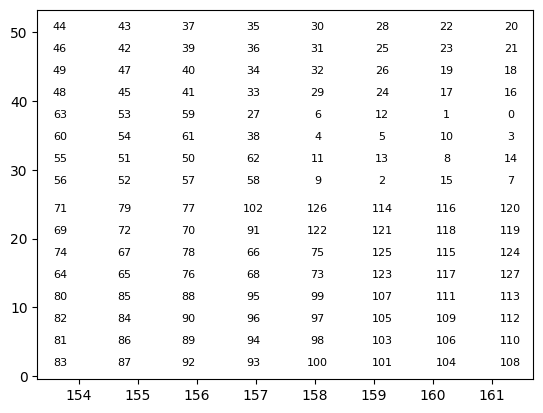

In [34]:
onemodule = map[3072:3200]
index = 0
for row in onemodule:
    plt.scatter(np.arctan2(row[1], row[0]) * 180 / np.pi, row[2], color='blue', s=0)
    plt.text(np.arctan2(row[1], row[0]) * 180 / np.pi, row[2], index, fontsize=8, ha='center', va='center')
    index += 1
print(row[0], row[1], row[2])
plt.show()

167.70030421472208


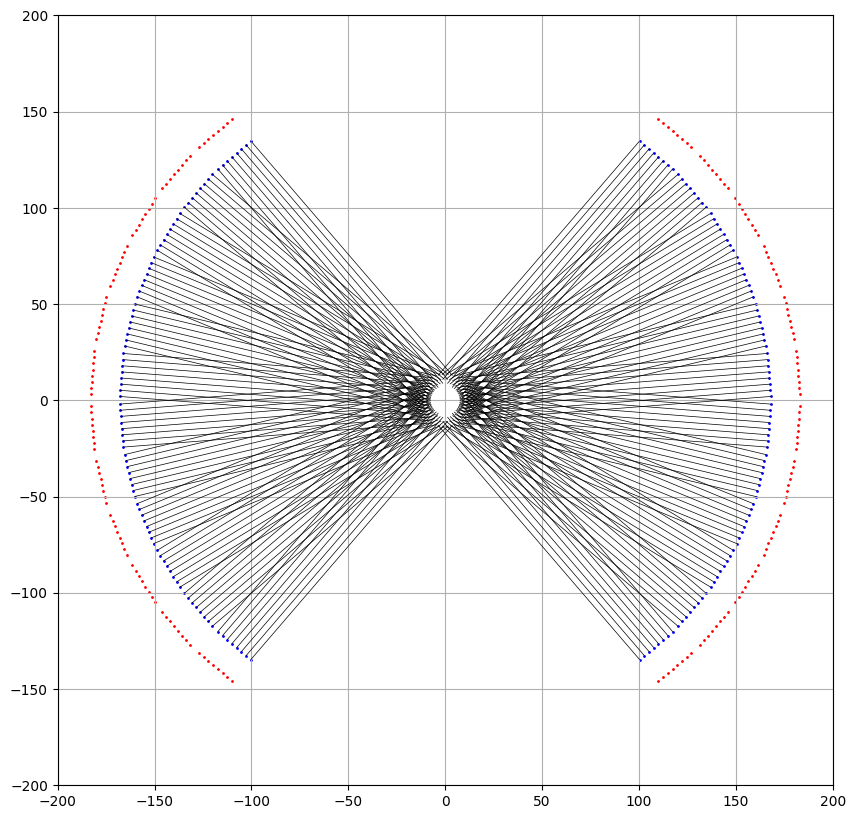

In [10]:
# Viewer
crystal_length = 15

topring = map[map[:,2] > 50]
#topring = mapcopy[mapcopy[:,2] > 50]
crystal_endpoints = np.column_stack((topring[:,0] + crystal_length * topring[:,3],
                             topring[:,1] + crystal_length * topring[:,4]))
plt.figure(figsize=(10,10))
plt.scatter(topring[:,0],topring[:,1], color='blue',s = 1)
plt.scatter(crystal_endpoints[:,0],crystal_endpoints[:,1], color='red',s = 1)
print(np.mean(np.sqrt(topring[:,0]**2 + topring[:,1]**2)))

# Scanner lines toward center
line_endpoints = np.column_stack((topring[:,0] - 160 * topring[:,3],
                                  topring[:,1] - 160 * topring[:,4]))

for i in range(len(topring)):
    plt.plot([topring[i,0],line_endpoints[i,0]], [topring[i,1],line_endpoints[i,1]], color='black',linewidth=0.5)
plt.grid(True)
plt.xlim(-200, 200)
plt.ylim(-200, 200)
plt.show()

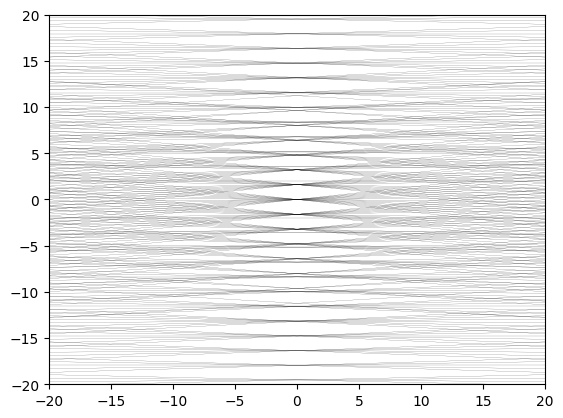

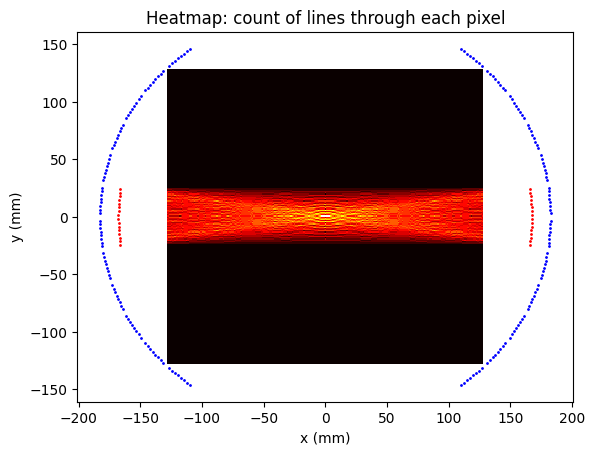

In [75]:
# Viewer
crystal_length = 15

topring = map[map[:,2] > 50]
#topring = mapcopy[mapcopy[:,2] > 50]
crystal_endpoints = np.column_stack((topring[:,0] + crystal_length * topring[:,3],
                             topring[:,1] + crystal_length * topring[:,4]))

center_modules = topring[np.abs(topring[:,1]) < 25]

for i in range(len(center_modules)):
    for j in range(i + 1, len(center_modules)):
        plt.plot([center_modules[i,0],center_modules[j,0]], [center_modules[i,1],center_modules[j,1]], color='black',linewidth=0.1)
plt.xlim(-20,20)
plt.ylim(-20, 20)

import numpy as np

# Define the 2D grid - choose pixel size, bounds
pixel_size = 1  # mm per pixel
x_min, x_max = -128, 128
y_min, y_max = -128, 128

x_bins = int((x_max - x_min) / pixel_size)
y_bins = int((y_max - y_min) / pixel_size)

heatmap = np.zeros((x_bins, y_bins), dtype=int)

# Helper: Bresenham's line algorithm in 2D pixel space
def bresenham_line(x0, y0, x1, y1):
    """Yields pixel indices a line from (x0, y0) to (x1, y1) passes through."""
    x0 = int(round((x0 - x_min) / pixel_size))
    y0 = int(round((y0 - y_min) / pixel_size))
    x1 = int(round((x1 - x_min) / pixel_size))
    y1 = int(round((y1 - y_min) / pixel_size))
    points = []

    dx = abs(x1 - x0)
    dy = abs(y1 - y0)
    x, y = x0, y0
    sx = 1 if x0 < x1 else -1
    sy = 1 if y0 < y1 else -1
    if dx > dy:
        err = dx / 2.0
        while x != x1:
            if 0 <= x < x_bins and 0 <= y < y_bins:
                points.append((x, y))
            err -= dy
            if err < 0:
                y += sy
                err += dx
            x += sx
        if 0 <= x1 < x_bins and 0 <= y1 < y_bins:
            points.append((x1, y1))
    else:
        err = dy / 2.0
        while y != y1:
            if 0 <= x < x_bins and 0 <= y < y_bins:
                points.append((x, y))
            err -= dx
            if err < 0:
                x += sx
                err += dy
            y += sy
        if 0 <= x1 < x_bins and 0 <= y1 < y_bins:
            points.append((x1, y1))
    return points

# For each pair as before, accumulate pixels along the connecting line
for i in range(len(center_modules)):
    for j in range(i + 1, len(center_modules)):
        x0, y0 = center_modules[i,0], center_modules[i,1]
        x1, y1 = center_modules[j,0], center_modules[j,1]
        for xb, yb in bresenham_line(x0, y0, x1, y1):
            heatmap[xb, yb] += 1

# Plot the heatmap
fig, ax = plt.subplots()
extent = [x_min, x_max, y_min, y_max]
ax.imshow(heatmap.T, origin='lower', extent=extent, cmap='hot', interpolation='nearest', aspect='auto')
ax.set_xlabel('x (mm)')
ax.set_ylabel('y (mm)')
ax.set_title('Heatmap: count of lines through each pixel')

plt.scatter(crystal_endpoints[:,0],crystal_endpoints[:,1], color='blue',s = 1)
plt.scatter(center_modules[:,0],center_modules[:,1], color='red',s = 1)

plt.grid(False)
plt.show()


In [31]:
# Save mapcopy as a CSV file
pd.DataFrame(mapcopy).to_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', index=False, header=False)


100%|██████████| 6144/6144 [00:06<00:00, 907.41it/s] 


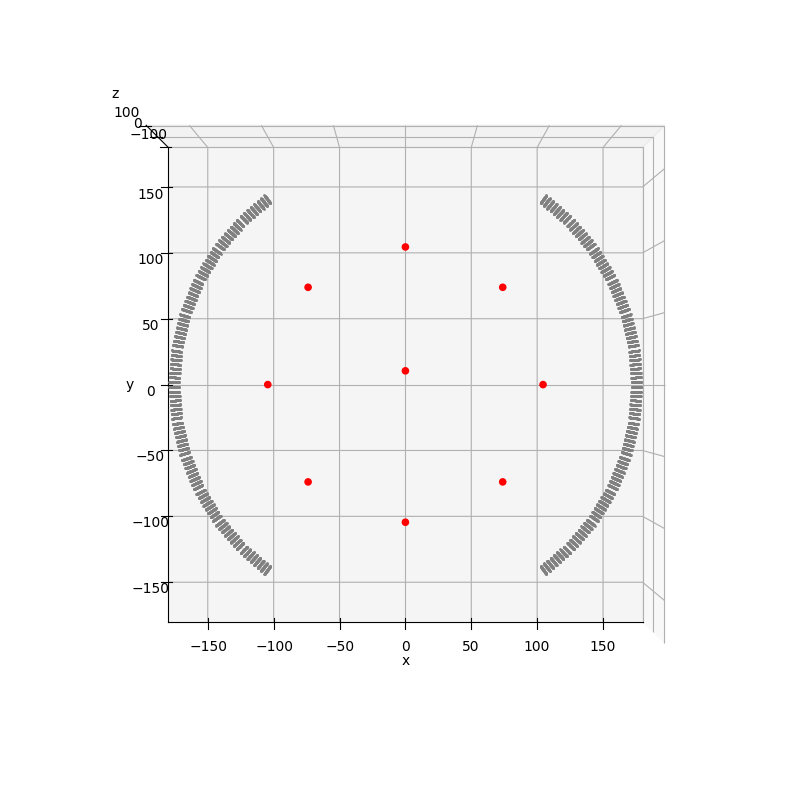

In [7]:
# Create a 3D plot of the scanner
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

half1=np.asarray(list(range(0, 27)) + list(range(28, 33)) + list(range(64, 73)) + list(range(76, 97)) + [74, 102])

for i in tqdm(range(len(map))):
    #if i % 128 in half1:
    #    ax.scatter(map[i, 0], map[i, 1], map[i, 2], marker='o', color = 'gray', alpha = 1, s=1)
    ax.scatter(map[i, 0], map[i, 1], map[i, 2], marker='o', color = 'gray', alpha = 1, s=1)

# Plot a single range
#modulenum = [9,14,34,37]
#for i in modulenum:
#    ax.scatter(map[:,0][i * 128: (i + 1) * 128], map[:,1][i * 128: (i + 1) * 128], map[:,2][i * 128: (i + 1) * 128], marker='o', color = 'red', alpha = 1, s=1)

# Draw the axes
#ax.plot([-120, 120], [0, 0], [0, 0], color = 'red', linewidth = 2)
#ax.plot([0, 0], [-120, 120], [0, 0], color = 'green', linewidth = 2)
#ax.plot([0, 0], [0, 0], [-60, 60], color = 'blue', linewidth = 2)
#xs = [0, 0, 100, 0, 0, 100]
#ys = [10, 100, 0, 10, 100, 0]
#zs = [0, 0, 0, -25, -25, -25]
xs = [0, 0, -70.7, -100, -70.7, 0, 70.7, 100, 70.7]
ys = [10, 100, 70.7, 0, -70.7, -100, -70.7, 0, 70.7]
zs = [0, 0, 0, 0, 0, 0, 0, 0, 0]
ax.scatter(xs, ys, zs, color = 'red', marker = 'o', s = 20, alpha = 1)

ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_zlim(-110, 110)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zticks([-100, 0, 100])
# Rotate view
#ax.view_init(elev=30, azim=225)
ax.view_init(elev=90, azim=270)
plt.show()

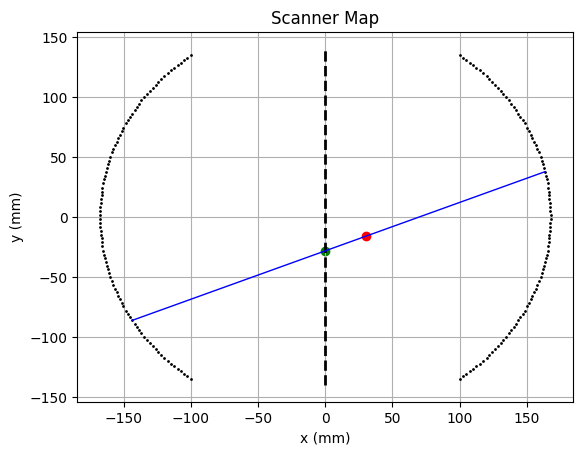

In [18]:
plt.plot(topring[:,0], topring[:,1], 'o', markersize = 1, color = 'black')
# Center source
#plt.plot(0, 0, 'o', markersize = 5, color = 'red')
# Vertical line source
plt.plot([0, 0], [-140, 140], color = 'black', linestyle = '--', linewidth = 2)
plt.plot([topring[60, 0], topring[180, 0]], [topring[60, 1], topring[180, 1]], color = 'blue', linewidth = 1)

def lor_line(x):
    dydx = (topring[180, 1] - topring[60, 1]) / (topring[180, 0] - topring[60, 0])
    x1, y1 = topring[60, 0], topring[60, 1]
    return y1 + dydx * (x - x1)

plt.scatter([0], [lor_line(0)], color = 'green')
plt.scatter([30], [lor_line(30)], color = 'red')

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.title('Scanner Map')
plt.grid()
plt.show()


In [13]:
# For creating test luts
import numpy as np
import pandas as pd
mapdf = pd.read_csv('/home/kale-chen/Documents/PET/TPPT_Scanner_map_adjusted.csv', usecols=[0,1,2,3,4,5], header=None)
map = mapdf.to_numpy()

section1 = map[map[:,0] < 0]
section1 = section1[section1[:,1] < -50]
section1 = section1[section1[:,2] > 40]

section2 = map[map[:,0] > 0]
section2 = section2[section2[:,1] > -20]
section2 = section2[section2[:,2] < -10]




print(len(section1))
print(len(section2))

total = np.concatenate((section1, section2), axis=0)

pd.DataFrame(total).to_csv('/home/kale-chen/Documents/PET/test_map.csv', index=False, header=False)
np.zeros((1,4), dtype = np.float32).tofile('/home/kale-chen/Documents/PET/test_map.bin')





132
702


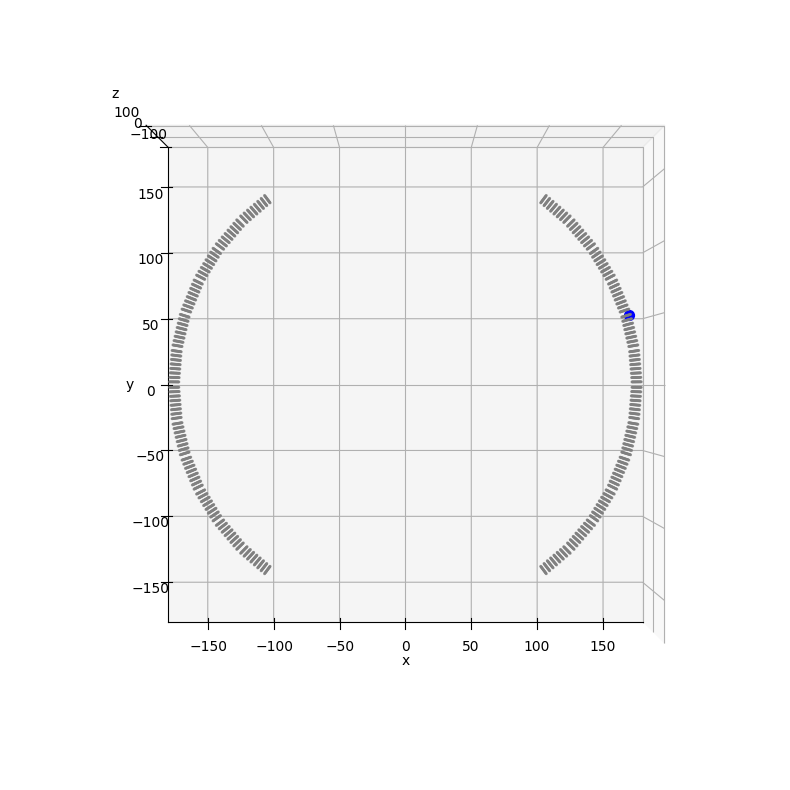

In [ ]:
# Create a 3D plot of the scanner
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

# Plot the scanner
plot_to = 4

#ax.scatter(map[:,0][:plot_to], map[:,1][:plot_to], map[:,2][:plot_to], marker='o', color = 'red', alpha = 0.5, s=5)

# Plot single crystal
#index = 2432
#index = 44
index = 1422
ax.scatter(map[:,0], map[:,1], map[:,2], marker='o', color = 'gray', alpha = 0.5, s=1)
ax.scatter(map[:,0][index], map[:,1][index], map[:,2][index], marker='o', color = 'blue', alpha = 1, s=50)

# Plot boundary points of circle run
boundangles = np.array([-1.12011132679, -2.02148132679, -4.26170398, -5.16307398])
boundangles = -boundangles
radius = 160
#ax.scatter(np.cos(boundangles) * radius, np.sin(boundangles) * radius, 0, marker='o', color = 'red', alpha = 1, s=40)
leftarcpath = np.linspace(boundangles[1], boundangles[2], 100)
#ax.plot(np.cos(leftarcpath) * radius, np.sin(leftarcpath) * radius, 0, color = 'red', linewidth = 2)
rightarcpath = np.linspace(boundangles[3], boundangles[0] + 2*np.pi, 100)
#ax.plot(np.cos(rightarcpath) * radius, np.sin(rightarcpath) * radius, 0, color = 'red', linewidth = 2)

#ax.plot([map[:,0][index], 0], [map[:,1][index], 0], [map[:,2][index], map[:,2][index]], color = 'blue', linewidth = 2, linestyle = '--')
#ax.plot([np.cos(boundangles[0]) * radius, 0], [-np.sin(boundangles[0]) * radius, 0], [0, 0], color = 'red', linewidth = 2, linestyle = '--')
#ax.plot([167, 0], [0, 0], [0, 0], color = 'black', linewidth = 2, linestyle = '--')

#randomleft, randomright = np.random.randint(3072, 6144), np.random.randint(0, 3072)
#ax.plot([map[:,0][randomleft], map[:,0][randomright]], [map[:,1][randomleft], map[:,1][randomright]], [map[:,2][randomleft], map[:,2][randomright]], color = 'black', linewidth = 2, linestyle = '--')

ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_zlim(-110, 110)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zticks([-100, 0, 100])
# Rotate view
#ax.view_init(elev=90, azim = 270)

plt.show()

np.int64(44)

In [74]:
row = map[44]
print((np.arctan2(row[1], row[0]) - 0.02) * 180 / np.pi)
print(boundangles[0] * 180 / np.pi)
print(- np.arctan2(row[1], row[0]) + 2*np.pi)


-54.470431092885164
64.17765160986595
7.213873674731126


167.70036255212898


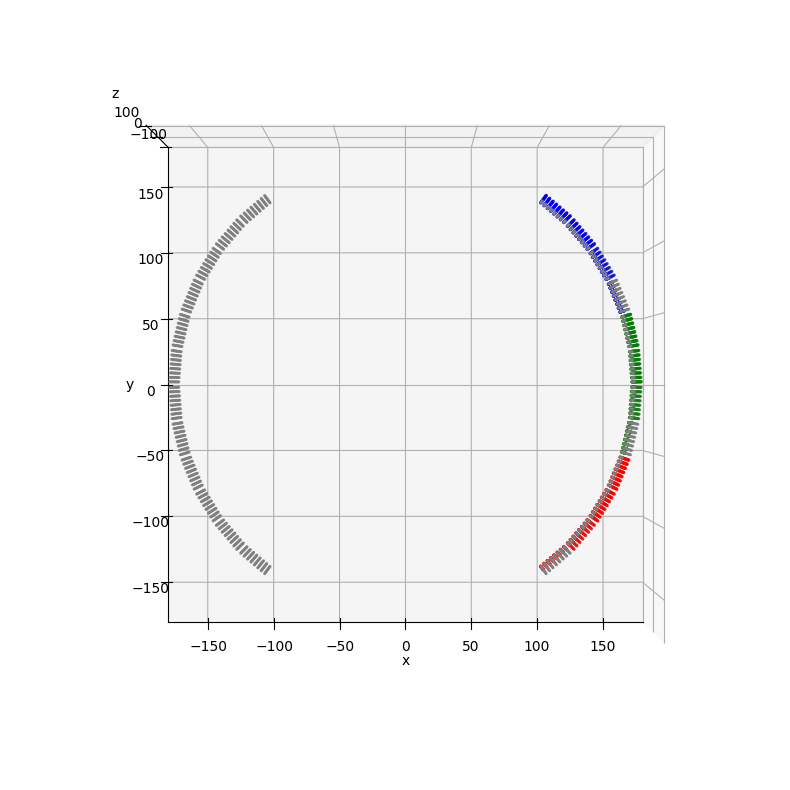

In [20]:
# Create a 3D plot of the scanner
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

slavecolors = ['red', 'green', 'blue']


ax.scatter(map[:,0], map[:,1], map[:,2], marker='o', color = 'gray', alpha = 0.5, s=1)
for port in range(1):
    port = port
    for slave in range(3):
        for febd in range(8):
            idrange = (port * 3072 + slave * 1024 + febd * 128, port * 3072 + slave * 1024 + febd * 128 + 128)
            ax.scatter(map[idrange[0]:idrange[1],0], map[idrange[0]:idrange[1],1], map[idrange[0]:idrange[1],2], marker='o', color = slavecolors[slave], alpha = febd/8, s=2)
ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_zlim(-110, 110)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zticks([-100, 0, 100])
# Rotate view
ax.view_init(elev=90, azim=270)
print(np.sqrt(np.mean(map[:,0]**2 + map[:,1]**2)))
plt.show()

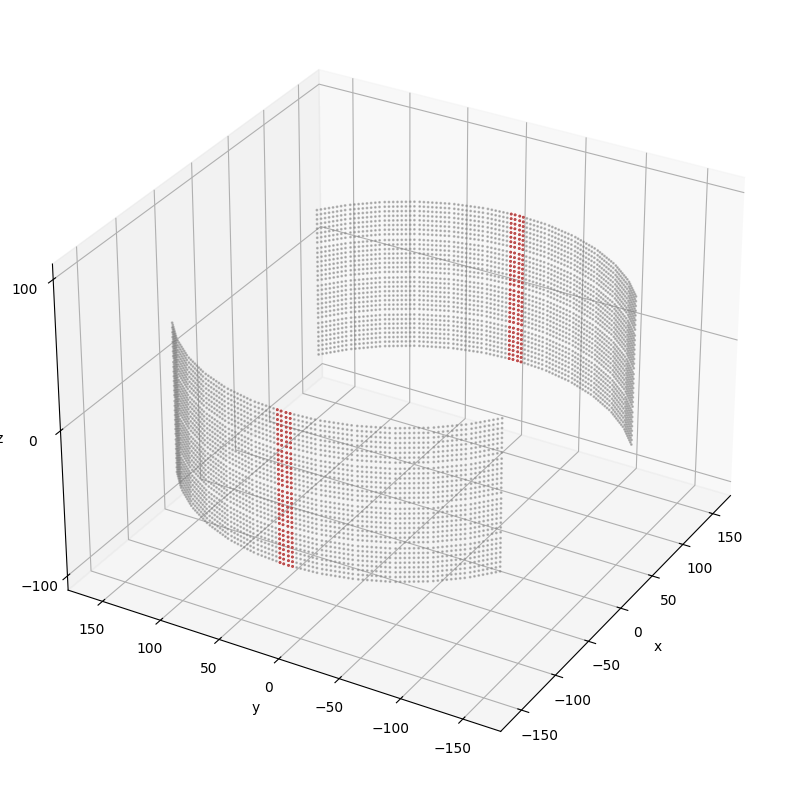

In [ ]:
# Create a 3D plot of the scanner
fig = plt.figure(figsize=(10,10))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(map[:,0], map[:,1], map[:,2], marker='o', color = 'gray', alpha = 0.5, s=1)

bound = 6
mask = (map[:,1] < bound) & (map[:,1] > -bound)
mask.tofile('/home/kale-chen/Documents/PET/mask.bin')
ax.scatter(map[mask,0], map[mask,1], map[mask,2], marker='o', color = 'red', alpha = 1, s=1)


ax.set_xlim(-180, 180)
ax.set_ylim(-180, 180)
ax.set_zlim(-110, 110)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')
ax.set_zticks([-100, 0, 100])
# Rotate view
ax.view_init(elev=30, azim = 210)

plt.show()

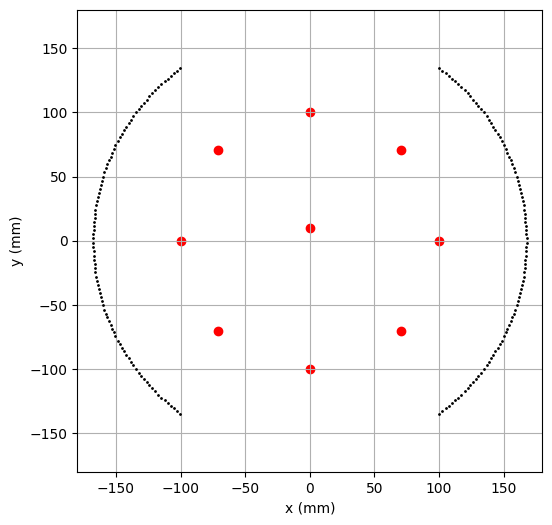

In [14]:
fig = plt.figure(figsize=(6,6))
plt.plot(topring[:,0], topring[:,1], 'o', markersize = 1, color = 'black')

plt.scatter(xs, ys, color = 'red')

plt.xlabel('x (mm)')
plt.ylabel('y (mm)')
plt.grid()
plt.xlim(-180, 180)
plt.ylim(-180, 180)
plt.show()
